# Load and Prepare Data

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [40]:
from google.colab import files
uploaded = files.upload()

Saving clean_fifa_worldcup_historical_data.xlsx to clean_fifa_worldcup_historical_data (1).xlsx


In [41]:
df = pd.read_excel("clean_fifa_worldcup_historical_data.xlsx")


In [42]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 965 entries, 0 to 964
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   home         965 non-null    object 
 1   away         965 non-null    object 
 2   year         965 non-null    int64  
 3   home_goals   964 non-null    float64
 4   away_goals   964 non-null    float64
 5   total_goals  964 non-null    float64
dtypes: float64(3), int64(1), object(2)
memory usage: 45.4+ KB


,home,away,year,home_goals,away_goals,total_goals
0,France,Mexico,1930,4.0,1.0,5.0
1,Argentina,France,1930,1.0,0.0,1.0
2,Chile,Mexico,1930,3.0,0.0,3.0
3,Chile,France,1930,1.0,0.0,1.0
4,Argentina,Mexico,1930,6.0,3.0,9.0


# Check missing values

In [43]:
df.isnull().sum()

,0
home,0
away,0
year,0
home_goals,1
away_goals,1
total_goals,1


In [44]:
# Remove rows with missing goal values
df = df.dropna()

# Verify again
print(df.isnull().sum())

home           0
away           0
year           0
home_goals     0
away_goals     0
total_goals    0
dtype: int64


# Remove duplicates

In [45]:
df.duplicated().sum()

np.int64(0)

# Question 1
Which national teams consistently perform best offensively in World Cup history?

In [46]:
# Home team goals
home_df = df[["home", "home_goals"]].copy()
home_df.columns = ["team", "goals_scored"]

# Away team goals
away_df = df[["away", "away_goals"]].copy()
away_df.columns = ["team", "goals_scored"]

# Combine both
teams_df = pd.concat([home_df, away_df], ignore_index=True)

# Remove missing values
teams_df = teams_df.dropna()

print(teams_df.head())

        team  goals_scored
0     France           4.0
1  Argentina           1.0
2      Chile           3.0
3      Chile           1.0
4  Argentina           6.0


# Calculate Offensive Metrics

In [47]:
team_attack = (
    teams_df
    .groupby("team")
    .agg(
        matches_played=("goals_scored", "count"),
        total_goals=("goals_scored", "sum"),
        avg_goals=("goals_scored", "mean")
    )
    .reset_index()
)

# Sort by total goals
team_attack = team_attack.sort_values(
    by="total_goals",
    ascending=False
)

print(team_attack.head(10))

            team  matches_played  total_goals  avg_goals
8         Brazil             114        237.0   2.078947
2      Argentina              88        152.0   1.727273
28        France              73        136.0   1.863014
83  West Germany              62        131.0   2.112903
39         Italy              83        128.0   1.542169
71         Spain              67        108.0   1.611940
26       England              74        104.0   1.405405
29       Germany              50        101.0   2.020000
46   Netherlands              55         96.0   1.745455
81       Uruguay              59         89.0   1.508475


# Most Efficient Attack

In [48]:
team_attack = (
    teams_df
    .groupby("team")
    .agg(
        matches_played=("goals_scored", "count"),
        total_goals=("goals_scored", "sum"),
        avg_goals=("goals_scored", "mean")
    )
    .reset_index()
)

# Sort by total goals
team_attack = team_attack.sort_values(
    by="avg_goals",
    ascending=False
)

print(team_attack.head(10))

            team  matches_played  total_goals  avg_goals
34       Hungary              32         87.0   2.718750
83  West Germany              62        131.0   2.112903
8         Brazil             114        237.0   2.078947
29       Germany              50        101.0   2.020000
77        Turkey              10         20.0   2.000000
28        France              73        136.0   1.863014
46   Netherlands              55         96.0   1.745455
56      Portugal              35         61.0   1.742857
2      Argentina              88        152.0   1.727273
60        Russia              14         24.0   1.714286


# Most Consistent Attacking Teams

In [49]:
# Filter teams with more than 30 matches
filtered_attack = team_attack[
    team_attack["matches_played"] > 30
]

# Sort by average goals
filtered_attack = filtered_attack.sort_values(
    by="avg_goals",
    ascending=False
)

print(filtered_attack.head(10))

            team  matches_played  total_goals  avg_goals
34       Hungary              32         87.0   2.718750
83  West Germany              62        131.0   2.112903
8         Brazil             114        237.0   2.078947
29       Germany              50        101.0   2.020000
28        France              73        136.0   1.863014
46   Netherlands              55         96.0   1.745455
56      Portugal              35         61.0   1.742857
2      Argentina              88        152.0   1.727273
70  Soviet Union              31         53.0   1.709677
84    Yugoslavia              33         55.0   1.666667


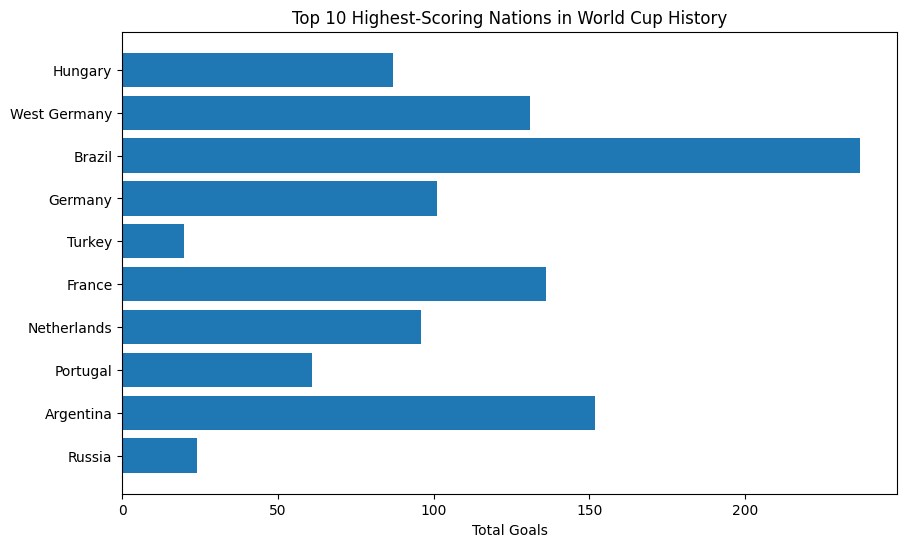

In [50]:
import matplotlib.pyplot as plt

top10 = team_attack.head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top10["team"],
    top10["total_goals"]
)

plt.xlabel("Total Goals")
plt.title("Top 10 Highest-Scoring Nations in World Cup History")

plt.gca().invert_yaxis()

plt.show()

# Question 2
Has the FIFA World Cup become more attacking or more defensive over time?

# Average Goals Per World Cup Year

In [51]:
goals_by_year = (
    df.groupby("year")
    .agg(
        matches=("total_goals", "count"),
        total_goals=("total_goals", "sum"),
        avg_goals=("total_goals", "mean")
    )
    .reset_index()
)

print(goals_by_year.head(50))

    year  matches  total_goals  avg_goals
0   1930       18         70.0   3.888889
1   1934       17         70.0   4.117647
2   1938       18         84.0   4.666667
3   1950       22         88.0   4.000000
4   1954       26        140.0   5.384615
5   1958       35        126.0   3.600000
6   1962       32         89.0   2.781250
7   1966       32         89.0   2.781250
8   1970       32         95.0   2.968750
9   1974       38         97.0   2.552632
10  1978       38        102.0   2.684211
11  1982       52        146.0   2.807692
12  1986       52        132.0   2.538462
13  1990       52        115.0   2.211538
14  1994       52        141.0   2.711538
15  1998       64        171.0   2.671875
16  2002       64        161.0   2.515625
17  2006       64        147.0   2.296875
18  2010       64        145.0   2.265625
19  2014       64        171.0   2.671875
20  2018       64        169.0   2.640625
21  2022       64        172.0   2.687500


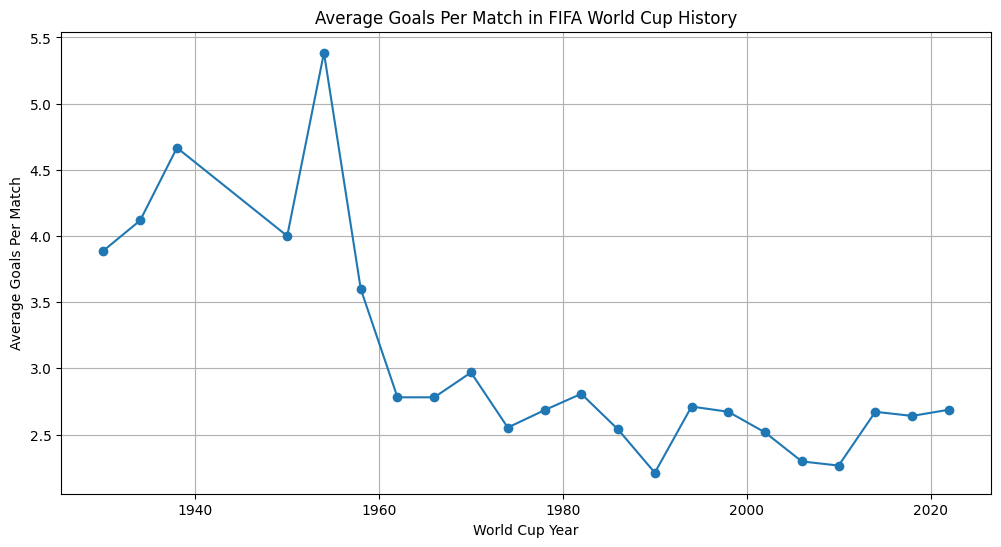

In [52]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(
    goals_by_year["year"],
    goals_by_year["avg_goals"],
    marker="o"
)

plt.title("Average Goals Per Match in FIFA World Cup History")
plt.xlabel("World Cup Year")
plt.ylabel("Average Goals Per Match")

plt.grid(True)

plt.show()

# Identify Highest-Scoring World Cups

In [53]:
highest_scoring = goals_by_year.sort_values(
    by="avg_goals",
    ascending=False
)

print(highest_scoring.head(10))

    year  matches  total_goals  avg_goals
4   1954       26        140.0   5.384615
2   1938       18         84.0   4.666667
1   1934       17         70.0   4.117647
3   1950       22         88.0   4.000000
0   1930       18         70.0   3.888889
5   1958       35        126.0   3.600000
8   1970       32         95.0   2.968750
11  1982       52        146.0   2.807692
7   1966       32         89.0   2.781250
6   1962       32         89.0   2.781250


# Identify Lowest-Scoring World Cups

In [54]:
lowest_scoring = goals_by_year.sort_values(
    by="avg_goals",
    ascending=True
)

print(lowest_scoring.head(10))

    year  matches  total_goals  avg_goals
13  1990       52        115.0   2.211538
18  2010       64        145.0   2.265625
17  2006       64        147.0   2.296875
16  2002       64        161.0   2.515625
12  1986       52        132.0   2.538462
9   1974       38         97.0   2.552632
20  2018       64        169.0   2.640625
15  1998       64        171.0   2.671875
19  2014       64        171.0   2.671875
10  1978       38        102.0   2.684211


# Goals by Decade

In [55]:
df["decade"] = (df["year"] // 10) * 10

decade_goals = (
    df.groupby("decade")["total_goals"]
    .mean()
    .reset_index()
)

print(decade_goals.head(50))

   decade  total_goals
0    1930     4.226415
1    1950     4.265060
2    1960     2.781250
3    1970     2.722222
4    1980     2.673077
5    1990     2.541667
6    2000     2.406250
7    2010     2.526042
8    2020     2.687500


In [56]:
df["goalless_draw"] = df["total_goals"] == 0

goalless_by_year = (
    df.groupby("year")["goalless_draw"]
    .mean()
    .reset_index()
)

print(goalless_by_year.head(50))

    year  goalless_draw
0   1930       0.000000
1   1934       0.000000
2   1938       0.000000
3   1950       0.000000
4   1954       0.000000
5   1958       0.057143
6   1962       0.125000
7   1966       0.093750
8   1970       0.093750
9   1974       0.131579
10  1978       0.157895
11  1982       0.134615
12  1986       0.076923
13  1990       0.096154
14  1994       0.057692
15  1998       0.062500
16  2002       0.046875
17  2006       0.109375
18  2010       0.109375
19  2014       0.109375
20  2018       0.015625
21  2022       0.109375


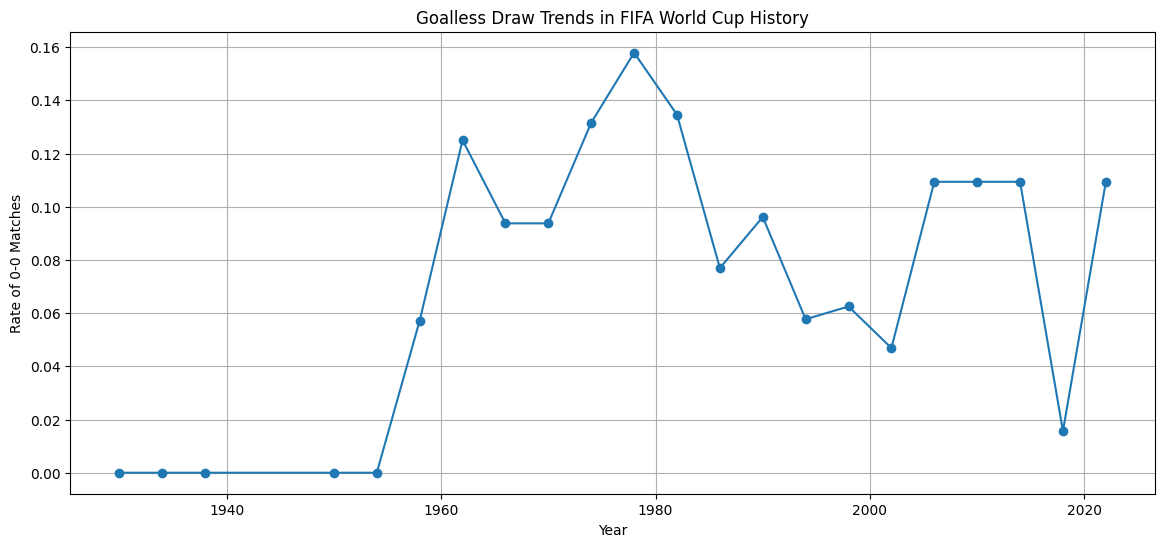

In [57]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.plot(
    goalless_by_year["year"],
    goalless_by_year["goalless_draw"],
    marker="o"
)

plt.title("Goalless Draw Trends in FIFA World Cup History")
plt.xlabel("Year")
plt.ylabel("Rate of 0-0 Matches")

plt.grid(True)

plt.show()

# Question 3
Which teams perform better as the “home-listed” side versus the “away-listed” side?

# Create Match Result Columns

In [58]:
# Home result
df["home_win"] = df["home_goals"] > df["away_goals"]

# Away result
df["away_win"] = df["away_goals"] > df["home_goals"]

# Draw
df["draw"] = df["home_goals"] == df["away_goals"]

# Overall Home vs Away Performance

In [59]:
home_stats = {
    "matches": len(df),
    "wins": df["home_win"].sum(),
    "goals_scored": df["home_goals"].sum(),
    "avg_goals": df["home_goals"].mean()
}

away_stats = {
    "matches": len(df),
    "wins": df["away_win"].sum(),
    "goals_scored": df["away_goals"].sum(),
    "avg_goals": df["away_goals"].mean()
}

print("Home Team Stats")
print(home_stats)

print("\nAway Team Stats")
print(away_stats)

Home Team Stats
{'matches': 964, 'wins': np.int64(524), 'goals_scored': np.float64(1703.0), 'avg_goals': np.float64(1.766597510373444)}

Away Team Stats
{'matches': 964, 'wins': np.int64(226), 'goals_scored': np.float64(1017.0), 'avg_goals': np.float64(1.0549792531120332)}


# Team-Level Home vs Away Analysis

In [60]:
home_team_stats = (
    df.groupby("home")
    .agg(
        home_matches=("home_goals", "count"),
        home_goals=("home_goals", "sum"),
        home_avg_goals=("home_goals", "mean"),
        home_wins=("home_win", "sum")
    )
    .reset_index()
)

print(home_team_stats.head())

        home  home_matches  home_goals  home_avg_goals  home_wins
0    Algeria             6         5.0        0.833333          1
1     Angola             1         0.0        0.000000          0
2  Argentina            63       122.0        1.936508         42
3  Australia             8         8.0        1.000000          3
4    Austria            14        32.0        2.285714         10


# Away Performance

In [61]:
away_team_stats = (
    df.groupby("away")
    .agg(
        away_matches=("away_goals", "count"),
        away_goals=("away_goals", "sum"),
        away_avg_goals=("away_goals", "mean"),
        away_wins=("away_win", "sum")
    )
    .reset_index()
)

print(away_team_stats.head())

        away  away_matches  away_goals  away_avg_goals  away_wins
0    Algeria             7         8.0        1.142857          2
1     Angola             2         1.0        0.500000          0
2  Argentina            25        30.0        1.200000          5
3  Australia            12         9.0        0.750000          1
4    Austria            15        11.0        0.733333          2


# Merge Home and Away Performance

In [62]:
team_comparison = pd.merge(
    home_team_stats,
    away_team_stats,
    left_on="home",
    right_on="away",
    how="outer"
)

print(team_comparison.head(10))

                     home  home_matches  home_goals  home_avg_goals  \
0                 Algeria           6.0         5.0        0.833333   
1                  Angola           1.0         0.0        0.000000   
2               Argentina          63.0       122.0        1.936508   
3               Australia           8.0         8.0        1.000000   
4                 Austria          14.0        32.0        2.285714   
5                 Belgium          24.0        41.0        1.708333   
6                 Bolivia           1.0         1.0        1.000000   
7  Bosnia and Herzegovina           1.0         3.0        3.000000   
8                  Brazil          86.0       190.0        2.209302   
9                Bulgaria           7.0        11.0        1.571429   

   home_wins                    away  away_matches  away_goals  \
0        1.0                 Algeria             7         8.0   
1        0.0                  Angola             2         1.0   
2       42.0        

<Axes: xlabel='Category'>

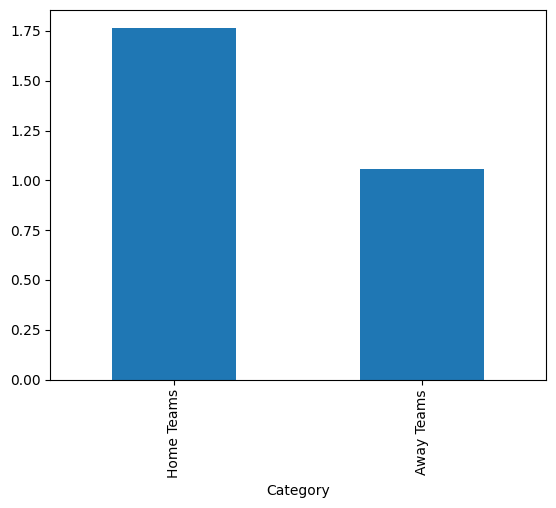

In [63]:
comparison = pd.DataFrame({
    "Category": ["Home Teams", "Away Teams"],
    "Average Goals": [
        df["home_goals"].mean(),
        df["away_goals"].mean()
    ]
})

comparison.plot(
    x="Category",
    y="Average Goals",
    kind="bar",
    legend=False
)

# Question 4
Which World Cup tournaments were the most entertaining for fans?

# Goals Per Tournament

In [64]:
tournament_stats = (
    df.groupby("year")
    .agg(
        matches=("total_goals", "count"),
        total_goals=("total_goals", "sum"),
        avg_goals=("total_goals", "mean")
    )
    .reset_index()
)

print(tournament_stats.head(50))

    year  matches  total_goals  avg_goals
0   1930       18         70.0   3.888889
1   1934       17         70.0   4.117647
2   1938       18         84.0   4.666667
3   1950       22         88.0   4.000000
4   1954       26        140.0   5.384615
5   1958       35        126.0   3.600000
6   1962       32         89.0   2.781250
7   1966       32         89.0   2.781250
8   1970       32         95.0   2.968750
9   1974       38         97.0   2.552632
10  1978       38        102.0   2.684211
11  1982       52        146.0   2.807692
12  1986       52        132.0   2.538462
13  1990       52        115.0   2.211538
14  1994       52        141.0   2.711538
15  1998       64        171.0   2.671875
16  2002       64        161.0   2.515625
17  2006       64        147.0   2.296875
18  2010       64        145.0   2.265625
19  2014       64        171.0   2.671875
20  2018       64        169.0   2.640625
21  2022       64        172.0   2.687500


# Add Entertainment Score

In [65]:
tournament_stats["entertainment_score"] = (
    tournament_stats["avg_goals"] * tournament_stats["matches"]
)

# Rank Most Entertaining World Cups

In [66]:
most_entertaining = tournament_stats.sort_values(
    by="avg_goals",
    ascending=False
)

print(most_entertaining.head(50))

    year  matches  total_goals  avg_goals  entertainment_score
4   1954       26        140.0   5.384615                140.0
2   1938       18         84.0   4.666667                 84.0
1   1934       17         70.0   4.117647                 70.0
3   1950       22         88.0   4.000000                 88.0
0   1930       18         70.0   3.888889                 70.0
5   1958       35        126.0   3.600000                126.0
8   1970       32         95.0   2.968750                 95.0
11  1982       52        146.0   2.807692                146.0
7   1966       32         89.0   2.781250                 89.0
6   1962       32         89.0   2.781250                 89.0
14  1994       52        141.0   2.711538                141.0
21  2022       64        172.0   2.687500                172.0
10  1978       38        102.0   2.684211                102.0
19  2014       64        171.0   2.671875                171.0
15  1998       64        171.0   2.671875              

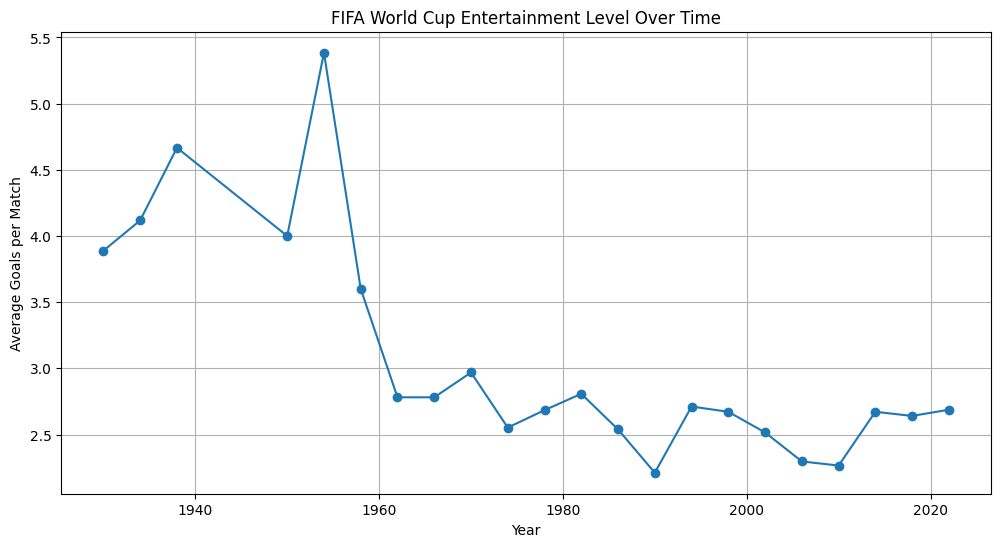

In [67]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(
    tournament_stats["year"],
    tournament_stats["avg_goals"],
    marker="o"
)

plt.title("FIFA World Cup Entertainment Level Over Time")
plt.xlabel("Year")
plt.ylabel("Average Goals per Match")

plt.grid(True)

plt.show()

# Question 5
Which matchups historically produce the highest-scoring games?

# Create Matchup Identifier

In [68]:
df["matchup"] = df.apply(
    lambda x: " vs ".join(sorted([x["home"], x["away"]])),
    axis=1
)

# Compute Matchup Goal Averages

In [69]:
matchup_stats = (
    df.groupby("matchup")
    .agg(
        matches=("total_goals", "count"),
        avg_goals=("total_goals", "mean"),
        total_goals=("total_goals", "sum")
    )
    .reset_index()
)

print(matchup_stats.head())

              matchup  matches  avg_goals  total_goals
0  Algeria vs Austria        1        2.0          2.0
1  Algeria vs Belgium        1        3.0          3.0
2   Algeria vs Brazil        1        1.0          1.0
3    Algeria vs Chile        1        5.0          5.0
4  Algeria vs England        1        0.0          0.0


# Find Most High-Scoring Matchups

In [70]:
high_volume_matchups = matchup_stats[
    matchup_stats["matches"] >= 3
]

top_matchups = high_volume_matchups.sort_values(
    by="avg_goals",
    ascending=False
)

print(top_matchups.head(10))

                     matchup  matches  avg_goals  total_goals
387   France vs West Germany        3   5.666667         17.0
151         Brazil vs Poland        4   5.000000         20.0
39       Argentina vs Mexico        4   4.500000         18.0
112  Belgium vs Soviet Union        3   4.333333         13.0
91   Austria vs West Germany        3   4.333333         13.0
28       Argentina vs France        4   4.250000         17.0
160         Brazil vs Sweden        7   4.142857         29.0
127          Brazil vs Chile        4   4.000000         16.0
97         Belgium vs France        3   3.666667         11.0
463     Italy vs Switzerland        3   3.666667         11.0


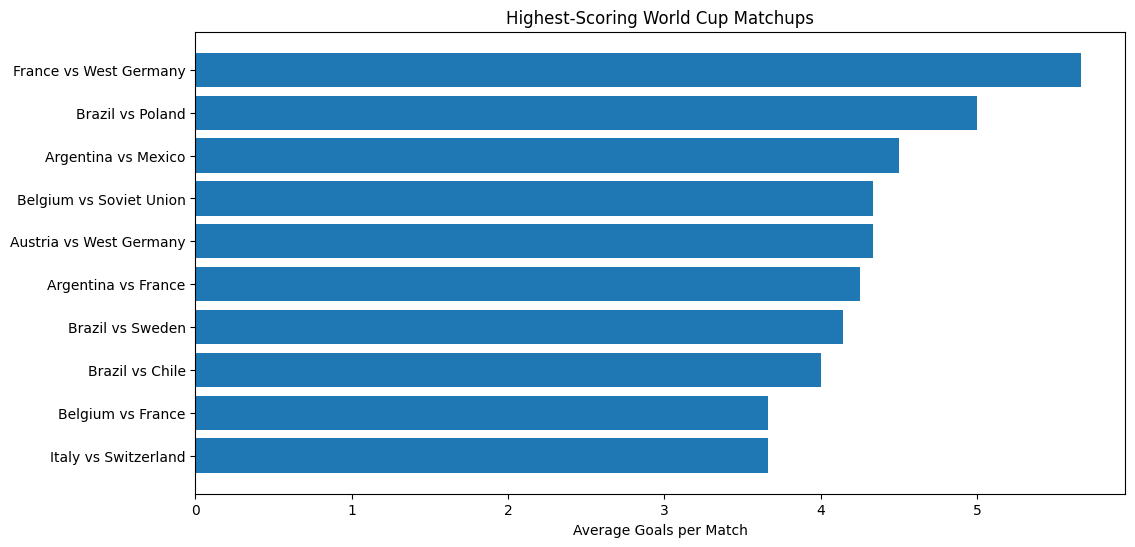

In [71]:
import matplotlib.pyplot as plt

top10 = top_matchups.head(10)

plt.figure(figsize=(12,6))

plt.barh(
    top10["matchup"],
    top10["avg_goals"]
)

plt.title("Highest-Scoring World Cup Matchups")
plt.xlabel("Average Goals per Match")

plt.gca().invert_yaxis()

plt.show()